In [4]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_curve, auc, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from datetime import datetime


In [5]:
class HSIPairDataset(Dataset):
    def __init__(self, csv_path, tensor_dir, label_column):
        self.df = pd.read_csv(csv_path)
        self.tensor_dir = tensor_dir
        self.label_column = label_column

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        A = torch.load(os.path.join(self.tensor_dir, row['tensor_A']), weights_only=True)
        B = torch.load(os.path.join(self.tensor_dir, row['tensor_B']), weights_only=True)

        label = torch.tensor(row[self.label_column], dtype=torch.float32)
        return A, B, label


class HSI_CNN_LSTM(nn.Module):
    def __init__(self, bands=149, hidden=128):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.lstm = nn.LSTM(32, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 64)

    def forward(self, x):
        B, bands, H, W = x.shape
        feats = []

        for b in range(bands):
            f = self.cnn(x[:, b:b+1])
            feats.append(f.view(B, -1))

        seq = torch.stack(feats, dim=1)
        out, _ = self.lstm(seq)
        return self.fc(out[:, -1])


In [6]:
def show_statistics(task_name, distances, labels, preds, threshold, roc_auc, acc):
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()

    same = distances[labels == 1]
    diff = distances[labels == 0]

    stats = {
        "Task": task_name,
        "Samples": len(labels),
        "Accuracy (%)": acc * 100,
        "AUC": roc_auc,
        "Threshold": threshold,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "Same Mean Dist": np.mean(same),
        "Same Std Dist": np.std(same),
        "Diff Mean Dist": np.mean(diff),
        "Diff Std Dist": np.std(diff)
    }

    df = pd.DataFrame([stats])
    display(df)

    print("Confusion Matrix:")
    display(pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    ))


In [7]:
def evaluate(task_name, label_column, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    dataset = HSIPairDataset(PAIR_CSV, TENSOR_DIR, label_column)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    distances, labels = [], []

    with torch.no_grad():
        for A, B, y in loader:
            A, B = A.to(device).float(), B.to(device).float()
            eA, eB = model(A), model(B)
            d = torch.norm(eA - eB, dim=1)
            distances.append(d.item())
            labels.append(y.item())

    distances = np.array(distances)
    labels = np.array(labels)

    fpr, tpr, th = roc_curve(labels, -distances)
    roc_auc = auc(fpr, tpr)
    idx = np.argmax(tpr - fpr)
    threshold = th[idx]

    preds = (-distances >= threshold).astype(int)
    acc = accuracy_score(labels, preds)

    # ================= ROC =================
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
    plt.plot([0,1],[0,1],'k--')
    plt.title(f"ROC – {task_name}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.grid()
    plt.show()

    plt.savefig(os.path.join(save_dir, "roc_curve.png"), dpi=300)
    plt.close()

    # ================= DISTANCES =================
    same = distances[labels == 1]
    diff = distances[labels == 0]

    plt.figure()
    plt.hist(same, bins=40, alpha=0.6, label="Positive")
    plt.hist(diff, bins=40, alpha=0.6, label="Negative")
    plt.axvline(-threshold, color='red', linestyle='--')
    plt.title(f"Distance Distribution – {task_name}")
    plt.legend()
    plt.grid()
    plt.show()

    plt.savefig(os.path.join(save_dir, "distance_distribution.png"), dpi=300)
    plt.close()

    # ================= CONFUSION MATRIX =================
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix – {task_name}")
    plt.show()

    plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=300)
    plt.close()

    # ================= STATISTICS =================
    show_statistics(
        task_name, distances, labels, preds,
        threshold, roc_auc, acc
    )

    # ================= SAVE FILES =================
    with open(os.path.join(save_dir, "metrics.json"), "w") as f:
        json.dump({
            "task": task_name,
            "accuracy": float(acc),
            "auc": float(roc_auc),
            "threshold": float(threshold),
            "samples": int(len(labels))
        }, f, indent=4)

    pd.DataFrame({
        "distance": distances,
        "label": labels,
        "prediction": preds
    }).to_csv(os.path.join(save_dir, "predictions.csv"), index=False)

    print(f"\n✅ {task_name} DONE | Accuracy: {acc*100:.2f}% | AUC: {roc_auc:.4f}")


In [8]:
PAIR_CSV   = r"D:\PEC\HSI_Project\processed\pair_index.csv"
TENSOR_DIR = r"D:\PEC\HSI_Project\tensors\sentences"
MODEL_PATH = r"D:\PEC\HSI_Project\checkpoints\day3_step3\hsi_cnn_lstm_contrastive.pt"

SAVE_WRITER = r"D:\PEC\HSI_Project\results\day3_step5\final_results\writer_verification"
SAVE_INK    = r"D:\PEC\HSI_Project\results\day3_step5\final_results\ink_mismatch"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = HSI_CNN_LSTM().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("✅ Model loaded")


✅ Model loaded


C:\Users\dell\AppData\Local\Temp\ipykernel_5728\2606224319.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=dev

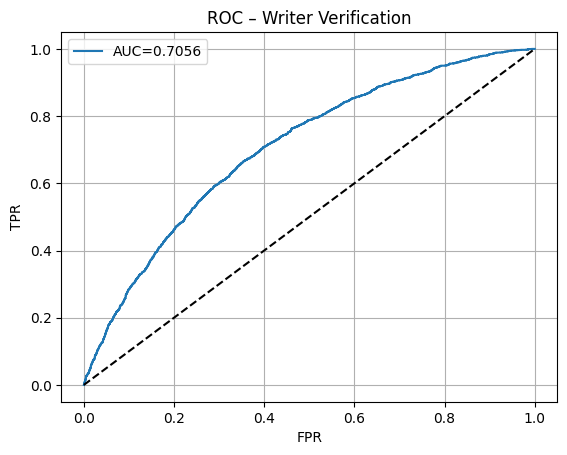

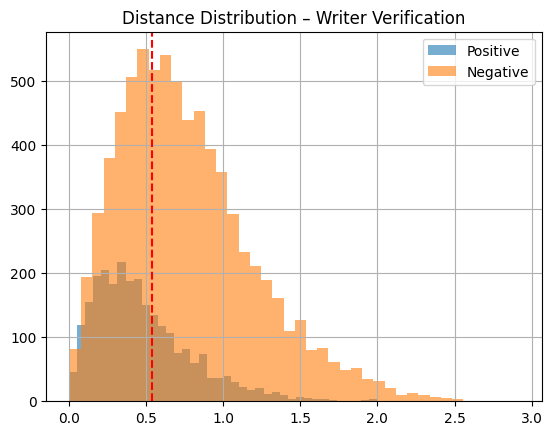

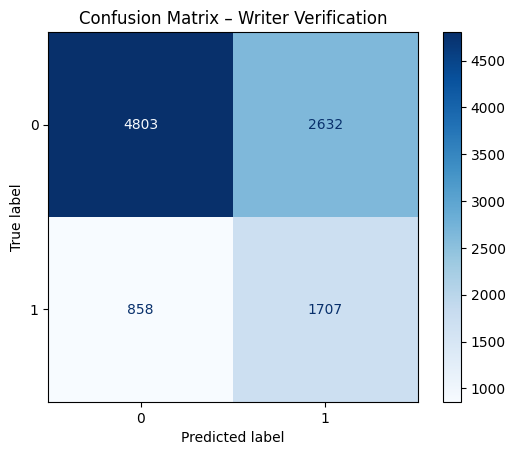

,Task,Samples,Accuracy (%),AUC,Threshold,TP,FP,TN,FN,Same Mean Dist,Same Std Dist,Diff Mean Dist,Diff Std Dist
0,Writer Verification,10000,65.1,0.705583,-0.542269,1707,2632,4803,858,0.480449,0.318845,0.766037,0.43844


Confusion Matrix:


,Pred 0,Pred 1
Actual 0,4803,2632
Actual 1,858,1707



✅ Writer Verification DONE | Accuracy: 65.10% | AUC: 0.7056


In [10]:
evaluate("Writer Verification", "same_writer", SAVE_WRITER)

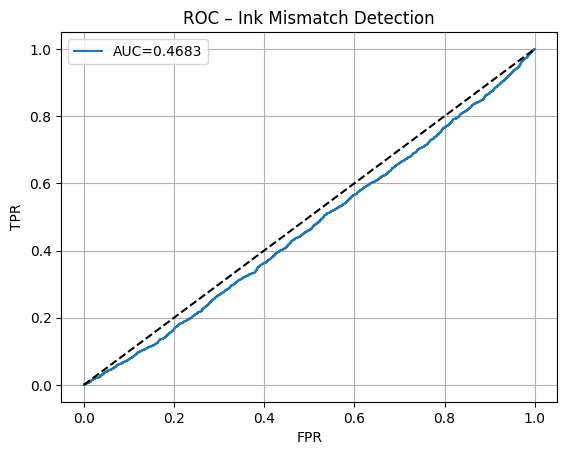

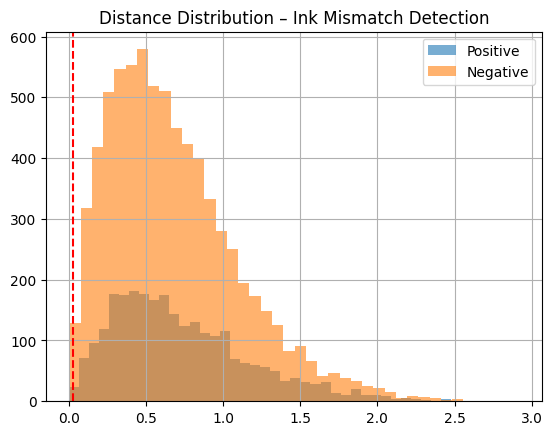

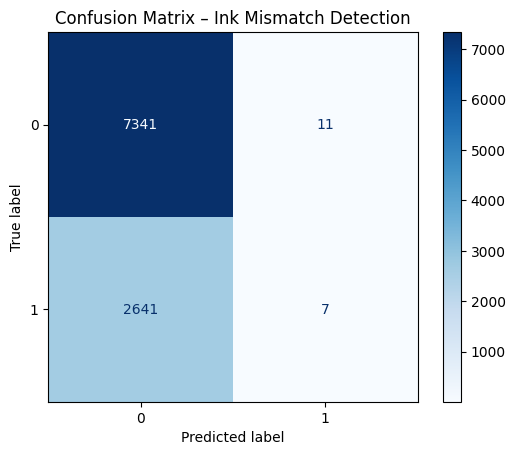

,Task,Samples,Accuracy (%),AUC,Threshold,TP,FP,TN,FN,Same Mean Dist,Same Std Dist,Diff Mean Dist,Diff Std Dist
0,Ink Mismatch Detection,10000,73.48,0.468334,-0.029165,7,11,7341,2641,0.730241,0.445413,0.679292,0.422943


Confusion Matrix:


,Pred 0,Pred 1
Actual 0,7341,11
Actual 1,2641,7



✅ Ink Mismatch Detection DONE | Accuracy: 73.48% | AUC: 0.4683


In [11]:
evaluate("Ink Mismatch Detection", "same_pen", SAVE_INK)

In [12]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_curve, auc, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve
)
from sklearn.manifold import TSNE


In [13]:
class HSIPairDataset(Dataset):
    def __init__(self, csv_path, tensor_dir, label_column):
        self.df = pd.read_csv(csv_path)
        self.tensor_dir = tensor_dir
        self.label_column = label_column

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        A = torch.load(f"{self.tensor_dir}/{r['tensor_A']}", weights_only=True)
        B = torch.load(f"{self.tensor_dir}/{r['tensor_B']}", weights_only=True)
        y = torch.tensor(r[self.label_column], dtype=torch.float32)
        return A, B, y


class HSI_CNN_LSTM(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.lstm = nn.LSTM(32, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 64)

    def forward(self, x):
        B, bands, _, _ = x.shape
        feats = [self.cnn(x[:, i:i+1]).view(B, -1) for i in range(bands)]
        seq = torch.stack(feats, dim=1)
        out, _ = self.lstm(seq)
        return self.fc(out[:, -1])


In [14]:
def evaluate_and_plot(task_name, label_column):
    dataset = HSIPairDataset(PAIR_CSV, TENSOR_DIR, label_column)
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    distances, labels, embeddings = [], [], []

    with torch.no_grad():
        for A, B, y in loader:
            A, B = A.to(device).float(), B.to(device).float()
            eA, eB = model(A), model(B)
            d = torch.norm(eA - eB, dim=1)
            distances.append(d.item())
            labels.append(y.item())
            embeddings.append(eA.squeeze().cpu().numpy())

    distances = np.array(distances)
    labels = np.array(labels)
    embeddings = np.array(embeddings)

    # ---------------- ROC
    fpr, tpr, th = roc_curve(labels, -distances)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'k--')
    plt.title(f"ROC Curve – {task_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()

    # ---------------- Precision–Recall
    p, r, _ = precision_recall_curve(labels, -distances)
    plt.figure()
    plt.plot(r, p)
    plt.title(f"Precision–Recall – {task_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid()
    plt.show()

    # ---------------- Threshold selection
    best_idx = np.argmax(tpr - fpr)
    threshold = th[best_idx]
    preds = (-distances >= threshold).astype(int)

    # ---------------- Confusion Matrix
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"Confusion Matrix – {task_name}")
    plt.show()

    # ---------------- Distance Distribution
    plt.figure()
    plt.hist(distances[labels==1], bins=40, alpha=0.6, label="Same")
    plt.hist(distances[labels==0], bins=40, alpha=0.6, label="Different")
    plt.axvline(-threshold, linestyle='--')
    plt.title(f"Distance Distribution – {task_name}")
    plt.legend()
    plt.grid()
    plt.show()

    # ---------------- Accuracy vs Threshold
    accs = [(accuracy_score(labels, (-distances >= t).astype(int))) for t in th]
    plt.figure()
    plt.plot(th, accs)
    plt.title(f"Accuracy vs Threshold – {task_name}")
    plt.xlabel("Threshold")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.show()

    # ---------------- FPR vs FNR
    fnr = 1 - tpr
    plt.figure()
    plt.plot(fpr, fnr)
    plt.title(f"FPR vs FNR – {task_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("False Negative Rate")
    plt.grid()
    plt.show()

    # ---------------- t-SNE Embedding
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure()
    plt.scatter(emb_2d[:,0], emb_2d[:,1], c=labels, cmap='coolwarm', s=5)
    plt.title(f"t-SNE Embedding – {task_name}")
    plt.colorbar(label="Class")
    plt.show()

    print(f"✅ {task_name} | AUC = {roc_auc:.4f}")


C:\Users\dell\AppData\Local\Temp\ipykernel_5728\2547790950.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=devi

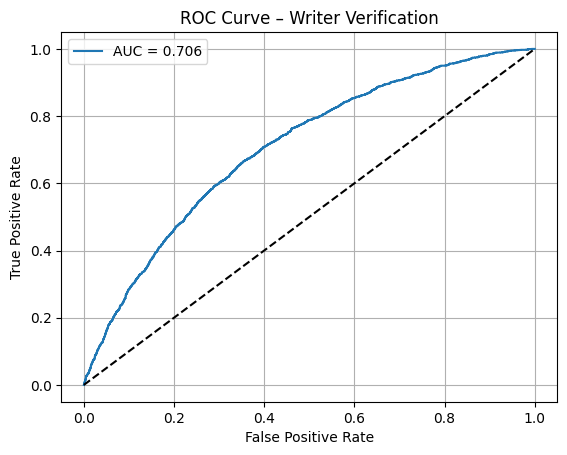

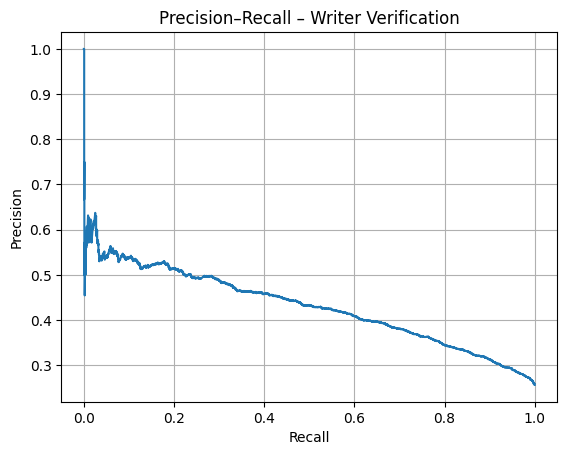

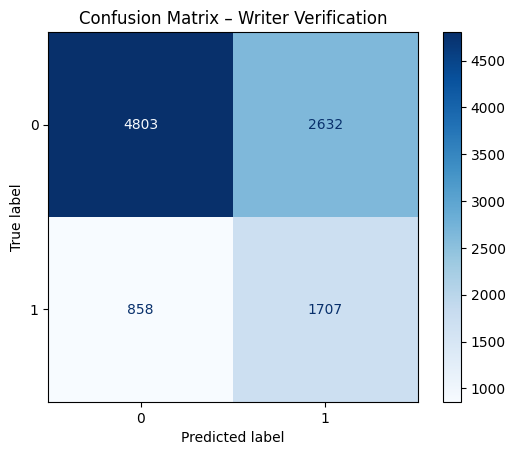

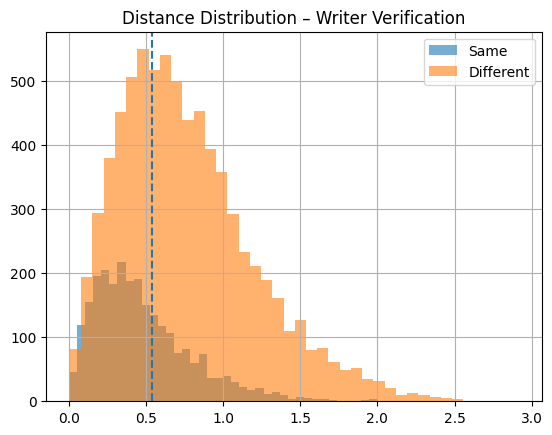

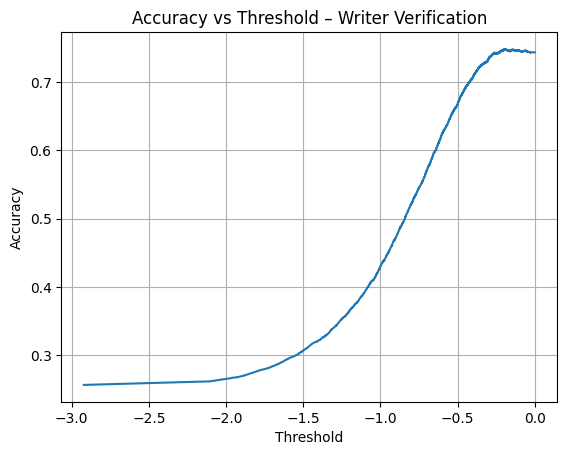

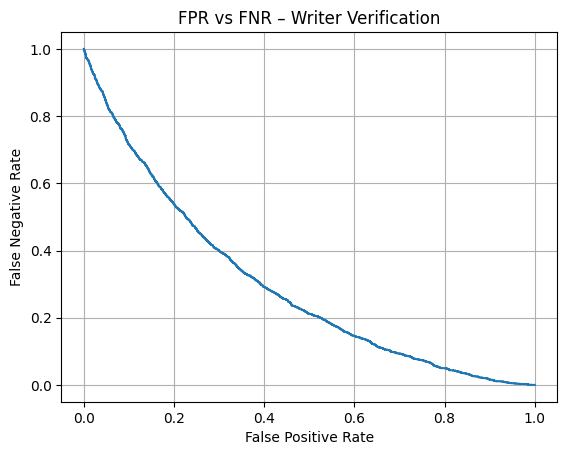

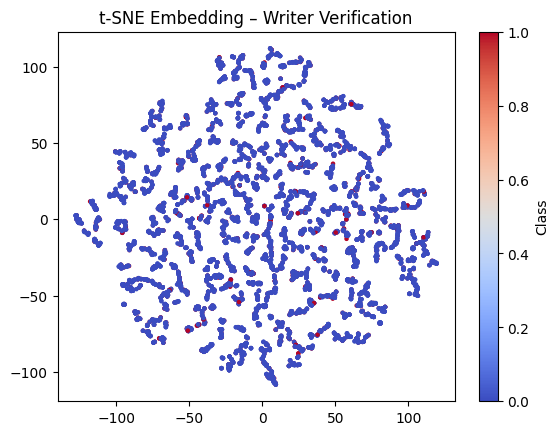

✅ Writer Verification | AUC = 0.7056


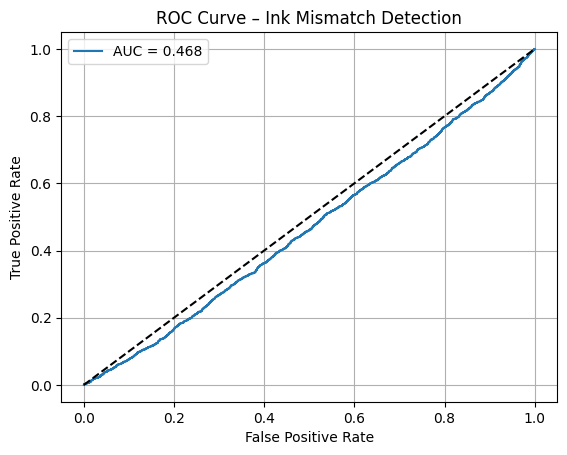

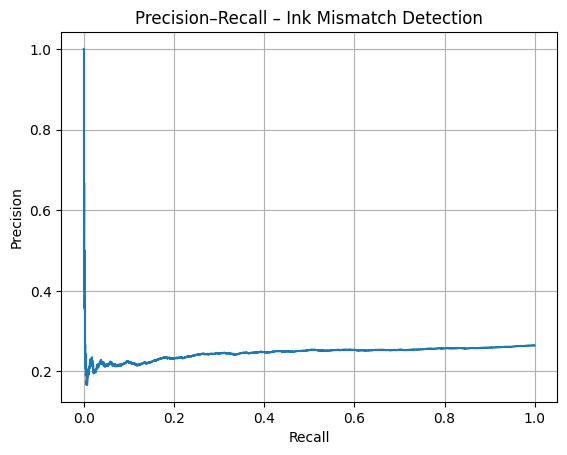

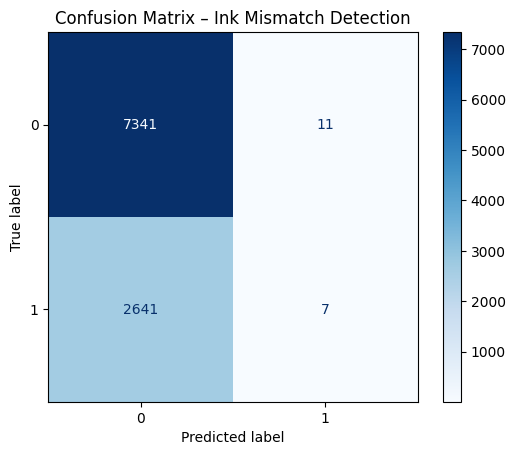

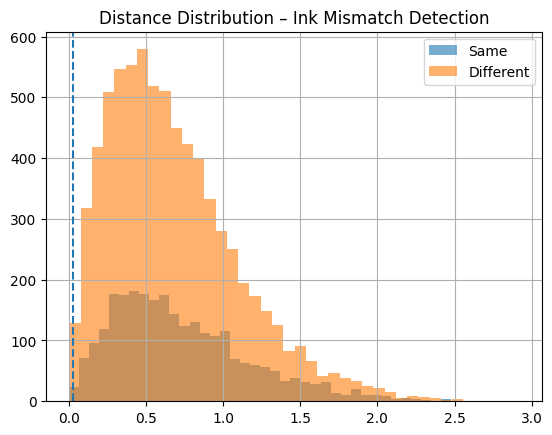

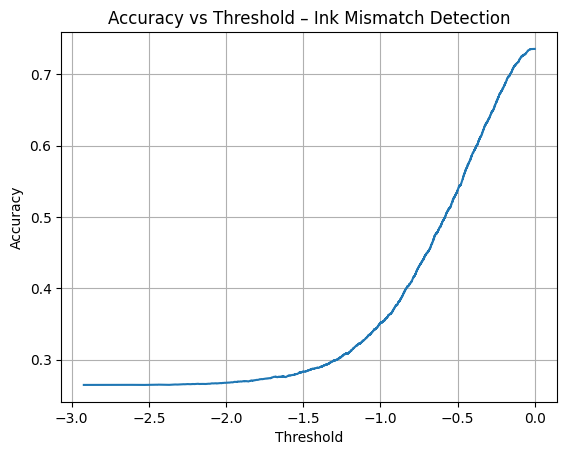

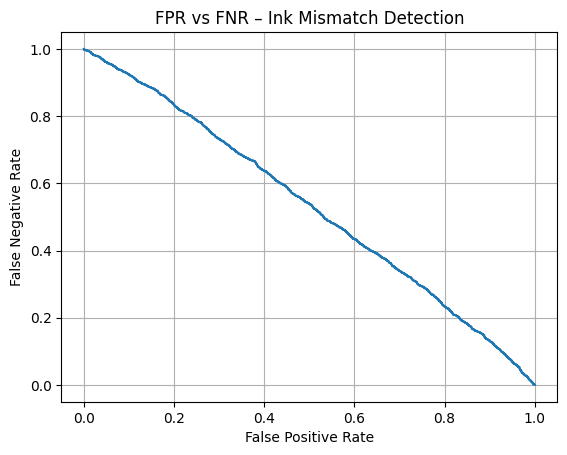

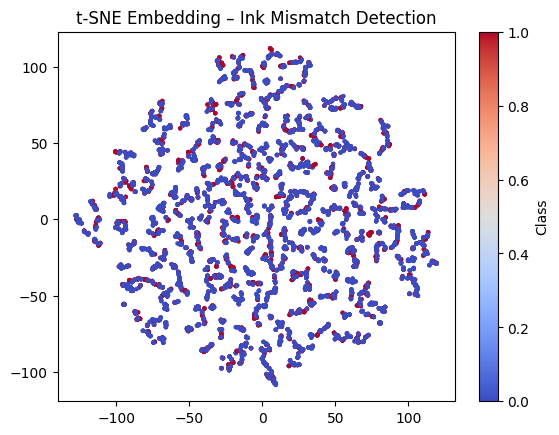

✅ Ink Mismatch Detection | AUC = 0.4683


In [15]:
PAIR_CSV   = r"D:\PEC\HSI_Project\processed\pair_index.csv"
TENSOR_DIR = r"D:\PEC\HSI_Project\tensors\sentences"
MODEL_PATH = r"D:\PEC\HSI_Project\checkpoints\day3_step3\hsi_cnn_lstm_contrastive.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = HSI_CNN_LSTM().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

evaluate_and_plot("Writer Verification", "same_writer")
evaluate_and_plot("Ink Mismatch Detection", "same_pen")
